## <center> **Linear regression**

In [1]:
# Input data (mouse weight and size)
import numpy as np
import pandas as pd

dic = {"mouseWeight": [0.9, 1.8, 2.4, 3.5, 3.9, 4.4, 5.1, 5.6, 6.3],
       "mouseSize": [1.4, 2.6, 1.0, 3.7, 5.5, 3.2, 3.0, 4.9, 6.3]}

df = pd.DataFrame(dic)

### Parameter estimation

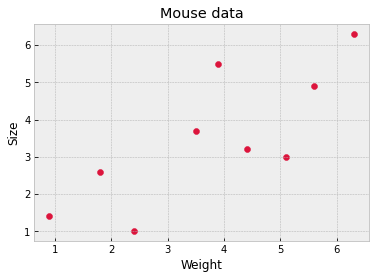

In [2]:
# Plot the data
import matplotlib.pyplot as plt

plt.style.use('bmh')
plt.scatter(df.mouseWeight, df.mouseSize, color="crimson")
plt.xlabel("Weight"); plt.ylabel("Size"); plt.title("Mouse data")
plt.show()

In [3]:
from sklearn.linear_model import LinearRegression

# Reshape the input data
y = df['mouseSize'].values.reshape(-1, 1)
X = df['mouseWeight'].values.reshape(-1, 1)

print(y.shape, X.shape, sep="\n")
# NOTE: Scikit-Learn's linear regression model expects a 2D input

(9, 1)
(9, 1)


In [4]:
# Create a linear regression model
lm = LinearRegression()
lm.fit(X, y);

print(f"b: {lm.intercept_}",
      f"a: {lm.coef_[0]}",
      sep="\n")

b: [0.58132051]
a: [0.77782051]


Equation for our model: 

#### $$ \text{y} = 0,77\text{x} + 0,58 $$

Where,
- $\text{y}: \text{mouse size}$
- $\text{x}: \text{mouse weight}$

In [5]:
# Get the p-values for slope and intercept
import statsmodels.api as sm

X_with_intercept = sm.add_constant(X)
model = sm.OLS(y, X_with_intercept)
results = model.fit()

p_value_slope = results.pvalues[1]
p_value_intercept = results.pvalues[0]

print(f"P-value for slope: {p_value_slope}",
      f"P-value for intercept: {p_value_intercept}",
      sep="\n")

P-value for slope: 0.012559062326425306
P-value for intercept: 0.5657839137981238


Generally speaking, we are usually not interested in the intercept, so it doesn´t matter its p-value. However, we want the p-value for weigth to be statistically significant (<0,05).

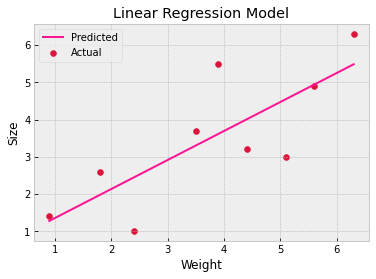

In [6]:
# Predict the size using the trained model
y_pred = lm.predict(X)

# Plot the fit
plt.scatter(df.mouseWeight, df.mouseSize, color='crimson', label='Actual')
plt.plot(df.mouseWeight, y_pred, color='deeppink', label='Predicted')
plt.xlabel('Weight')
plt.ylabel('Size')
plt.title('Linear Regression Model')
plt.legend()
plt.show()

### R-squared and p-value

In [7]:
# Calculate R-squared and p-value
import scipy.stats as stats

slope, intercept, r_value, p_value, std_err = stats.linregress(df.mouseWeight, df.mouseSize)

print(f'R-squared: {r_value**2}',
      f'p-value: {p_value}',
      sep="\n")

R-squared: 0.6132867420657666
p-value: 0.012559062326425298


This means that weight can explain 61% of the variation in size ! This is good !!

The p-value (<0,05) tells us that weight gives us a reliable estimate for size.

In [8]:
# Calculate adjusted R-squared

R2 = r_value**2
num_indep_vars = (len(lm.coef_) + 1) - 1 # Get the number of independent variables (excluding the constant)
n = len(df) # Get the number of data points

adjusted_R2 = 1 - (1 - R2) * (n - 1) / (n - num_indep_vars - 1)

print("Adjusted R-squared:", adjusted_R2)

Adjusted R-squared: 0.5580419909323047


The adjusted R-squared penalizes the R-squared for including additional independent variables that may not significantly improve the model fit. It is a useful metric when comparing models with different numbers of independent variables.

### Residuals

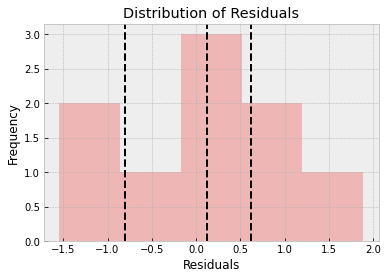

In [9]:
# Plot the histogram of residuals

residuals = y - y_pred

plt.hist(residuals, bins='auto', color='lightcoral', alpha=0.5)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')

quantiles = np.quantile(residuals, [0.25, 0.5, 0.75])
for q in quantiles:
    plt.axvline(q, color='black', linestyle='--')

plt.show()

In order to get a good fit the residuals should be normallly distributed:
- min and max should we same distance from the cero
- 1Q and 3Q also should we same distance from the cero
- median should be close to cero

---